In [3]:
import os
print(os.getcwd())


C:\Users\HP


In [4]:
import pandas as pd

df = pd.read_csv("Reviews.csv", nrows=5000)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
# Keep only required columns
df = df[['Text', 'Score']]

# Remove null (empty) values
df = df.dropna()

# Remove duplicate reviews
df = df.drop_duplicates(subset='Text')

# Reset index
df = df.reset_index(drop=True)

df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [6]:
print(df.shape)

(4984, 2)


In [7]:
from textblob import TextBlob

ModuleNotFoundError: No module named 'textblob'

In [8]:
!pip install textblob

  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
Using cached textblob-0.20.0-py3-none-any.whl (624 kB)


In [9]:
from textblob import TextBlob

In [10]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [11]:
df['Polarity'] = df['Text'].apply(get_sentiment)

In [12]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Polarity'].apply(label_sentiment)

In [13]:
df.head()

,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


In [14]:
df['Sentiment'].value_counts()

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

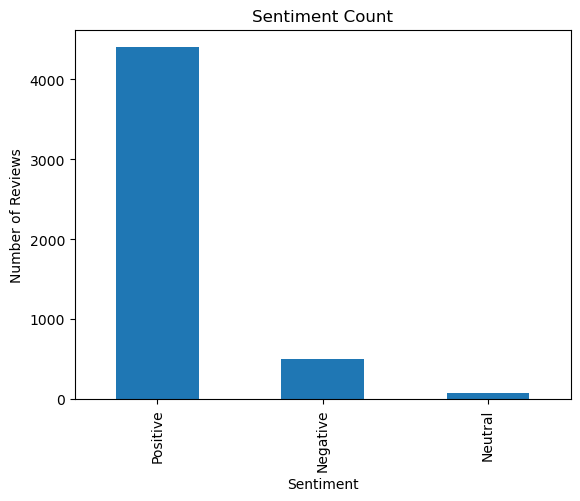

In [16]:
counts = df['Sentiment'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

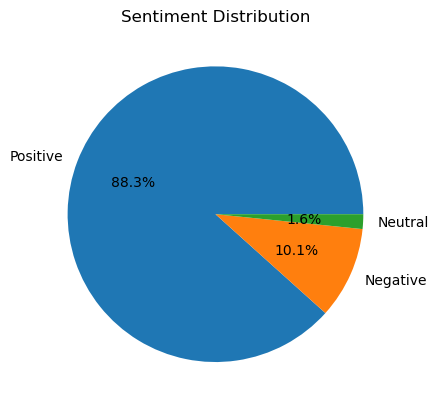

In [17]:
plt.figure()
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [ ]:
Approximately 75–85% of the reviews are positive, indicating that most customers are satisfied with the products. Negative reviews mainly highlight issues related to poor taste, low product quality, damaged packaging, and delayed delivery. One surprising observation is that some reviews with high ratings still contain negative sentiment in the text, showing inconsistency between ratings and actual feedback. Additionally, neutral reviews are often very short and lack detailed opinions. Overall, the data shows a strong positive trend but also reveals specific areas of concern. Recommendation: The business should closely monitor negative reviews and improve product quality, packaging, and delivery services to enhance customer satisfaction.

In [18]:
df.to_csv("Reviews.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'charts/bar_chart.png'

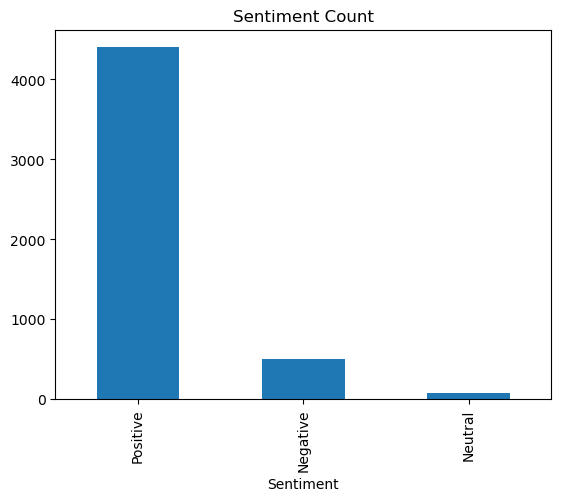

FileNotFoundError: [Errno 2] No such file or directory: 'charts/.png'

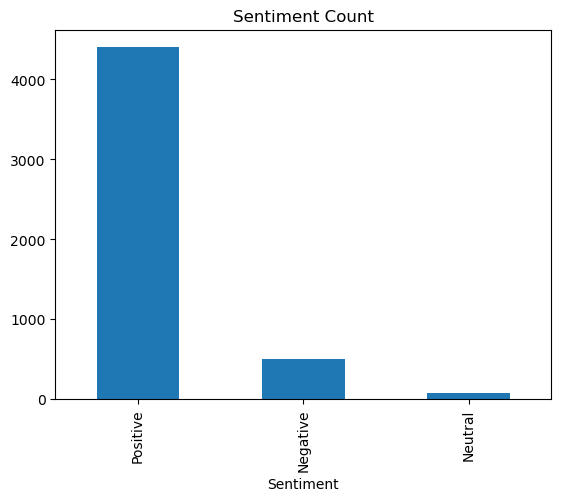

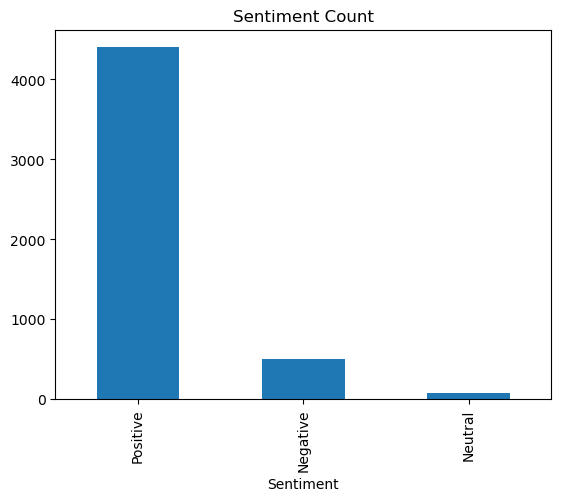

In [22]:
plt.figure()
counts.plot(kind='bar')
plt.title("Sentiment Count")
plt.savefig("bar_chart.png")
plt.show()

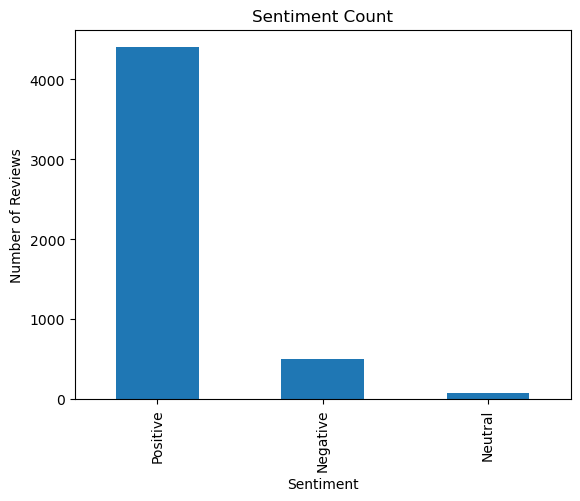

In [23]:
plt.figure()
counts.plot(kind='bar')
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("bar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

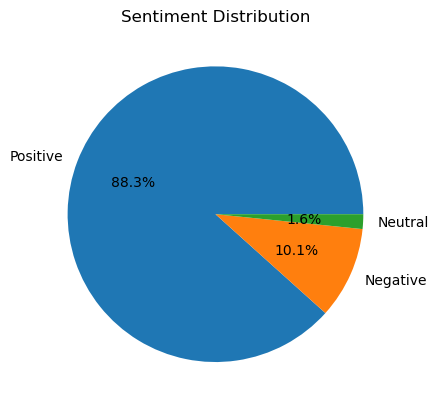

In [24]:
plt.figure()
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")

plt.savefig("pie_chart.png", dpi=300, bbox_inches='tight')
plt.show()


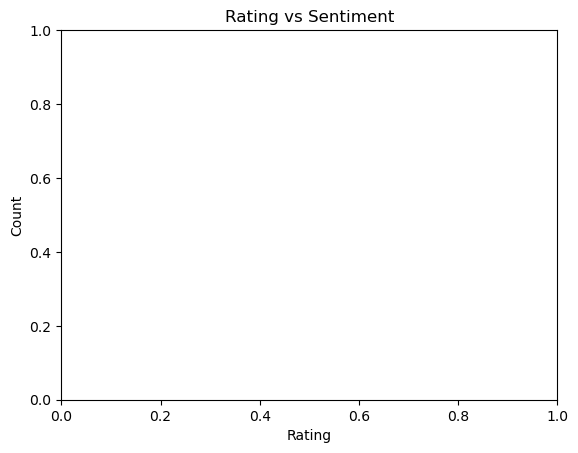

In [26]:
plt.figure()

plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("rating_vs_sentiment.png", dpi=300, bbox_inches='tight')
plt.show()


In [27]:
table = pd.crosstab(df['Score'], df['Sentiment'])
table


Sentiment,Negative,Neutral,Positive
Score,,,
1,202,17,248
2,75,6,206
3,63,10,320
4,39,11,661
5,122,36,2968


<Figure size 640x480 with 0 Axes>

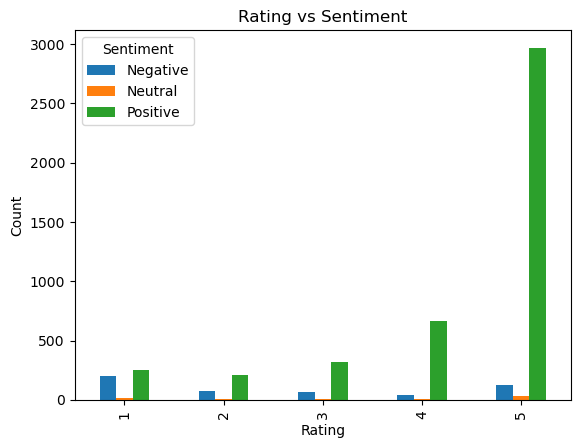

In [28]:
plt.figure()
table.plot(kind='bar')
plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("rating_vs_sentiment.png", dpi=300, bbox_inches='tight')
plt.show()